In [2]:
import pandas as pd
import numpy as np
import spikeinterface.extractors as se
import spikeinterface.preprocessing as sp
import matplotlib.pyplot as plt
import neurokit2 as nk
import spikeinterface.extractors as se
import glob
import os
import h5py
import numpy as np
from scipy.signal import butter, filtfilt, resample_poly
from scipy.signal import find_peaks
from collections import defaultdict
import math


In [62]:
BOUT_FILE = r"D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\BORIS_csv\cohort2_RI1_social_bouts.csv"

social_bouts = pd.read_csv(BOUT_FILE)

print(social_bouts.shape)
print(social_bouts.head())

(2112, 8)
  SubjectID Group Laser             Behavior    Start     Stop  Duration  \
0      14_2   GFP    ON        body sniffing  188.600  227.533    38.933   
1      14_4   GFP   OFF  anogenital sniffing   82.800  109.132    26.332   
2      14_2   GFP    ON        body sniffing  164.999  188.133    23.134   
3      14_2   GFP    ON        body sniffing  146.133  164.267    18.134   
4      13_4   ChR    ON  anogenital sniffing  104.200  121.266    17.066   

                                     File  
0   14_2_RI1_i_on_20260712_142852.rec.csv  
1  14_4_RI1_i_off_20260712_130141.rec.csv  
2   14_2_RI1_i_on_20260712_142852.rec.csv  
3   14_2_RI1_i_on_20260712_142852.rec.csv  
4       13_4_RI1_e_on_20260711_123305.csv  


In [7]:
H5_DIRS = {
    # --- Cohort 2 RI1 ---
    "RI1_day1": r"D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs",
}

In [8]:
all_files = []

for folder in H5_DIRS.values():
    for fname in os.listdir(folder):
        if fname.endswith(".h5"):
            all_files.append(os.path.join(folder, fname))

print("Total files:", len(all_files))


Total files: 44


In [9]:
for f in all_files:
    print(f)


D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_1_RI1_c_on_20260711_105641.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_1_RI1_e_off_20260712_102415.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_2_RI1_b_on_20260712_125143.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_2_RI1_l_off_20260711_132243.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_3_RI1_b_on_20260711_142620.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_3_RI1_e_off_20260712_135803.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_4_RI1_k_off_20260711_122241.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\10_4_RI1_p_on_20260712_111439.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\11_2_RI1_d_on_20260712_131331.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\11_2_RI1_p_off_20260711_134956.h5
D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\11_3_

Helper functions 

In [10]:
def get_sniff_respiratory_rate(
    signal,
    time,
    sniff_start,
    sniff_end,
    sampling_rate=100,
    max_rate_hz=12
):
    """
    Compute average respiration/sniff rate using inter-breath intervals (IBI).
    
    Returns:
        avg_rate_hz (float) or np.nan
    """

    # -----------------------------
    # Mask window
    # -----------------------------
    sniff_mask = (time >= sniff_start) & (time < sniff_end)

    if sniff_mask.sum() < sampling_rate:  # <1 s of data
        return np.nan

    signal_sniff = signal[sniff_mask]
    time_sniff = time[sniff_mask]

    # -----------------------------
    # Pre-clean for peak detection
    # -----------------------------
    signal_sniff = signal_sniff - np.mean(signal_sniff)

    # -----------------------------
    # Peak detection
    # -----------------------------
    min_ibi = 1.0 / max_rate_hz
    min_distance = int(min_ibi * sampling_rate)

    peaks, _ = find_peaks(
        signal_sniff,
        distance=min_distance
    )

    if len(peaks) < 2:
        return np.nan

    # -----------------------------
    # IBI and rate
    # -----------------------------
    peak_times = time_sniff[peaks]
    ibi = np.diff(peak_times)          # seconds
    inst_rate = 1.0 / ibi              # Hz

    return np.mean(inst_rate)


In [11]:
def load_resp_simple(h5_file, target_rate=100, trodes_rate=20000):
    import h5py
    import numpy as np
    from scipy.signal import butter, filtfilt, resample_poly
    import neurokit2 as nk

    with h5py.File(h5_file, 'r') as f:
        resp_key = [k for k in f['analog'].keys() if "Ain1" in k][0]
        resp = f['analog'][resp_key][()]['voltage'].astype(float)

    # Time relative to recording start
    t = np.arange(len(resp)) / trodes_rate

    # Clean
    resp -= np.median(resp)
    mad = np.median(np.abs(resp))
    if mad > 0:
        resp = np.clip(resp, -10 * mad, 10 * mad)

    # Low-pass + downsample
    nyq = trodes_rate / 2
    b, a = butter(4, (target_rate / 2) / nyq, btype="low")
    resp_filt = filtfilt(b, a, resp)

    down = int(trodes_rate // target_rate)
    resp_ds = resample_poly(resp_filt, up=1, down=down)
    t_ds = t[::down]

    # Bandpass
    resp_clean = nk.signal_filter(
        resp_ds,
        lowcut=0.1,
        highcut=20,
        sampling_rate=target_rate,
        order=2
    )

    return resp_clean, t_ds


Define social time 

In [38]:
SOCIAL_START = 60
SOCIAL_END   = 240


In [43]:
h5_file = r"D:\BLA_ChR_resp_cohort2\BLA_ChR_resp_RI1_hc_day1\h5_outputs\13_1_RI1_a_off_20260711_140435.h5"


In [44]:
rsp, t = load_resp_simple(h5_file)

social_rate = get_sniff_respiratory_rate(
    signal=rsp,
    time=t,
    sniff_start=SOCIAL_START,
    sniff_end=SOCIAL_END,
    sampling_rate=100
)

print("Social respiration rate (Hz):", social_rate)


Social respiration rate (Hz): 10.083056965230693


In [45]:
rows = []

for h5_file in all_files:
    
    fname = os.path.basename(h5_file)
    parts = fname.split("_")
    
    subject = "_".join(parts[0:2])
    condition = parts[2]
    laser = "ON" if "_on_" in fname else "OFF"
    
    rsp, t = load_resp_simple(h5_file)
    
    rate = get_sniff_respiratory_rate(
        signal=rsp,
        time=t,
        sniff_start=SOCIAL_START,
        sniff_end=SOCIAL_END,
        sampling_rate=100
    )
    
    rows.append({
        "Subject": subject,
        "Condition": condition,
        "Laser": laser,
        "RespRate": rate,
        "File": fname
    })

df_resp = pd.DataFrame(rows)

print("df_resp rebuilt.")
print("Subjects:", df_resp["Subject"].nunique())


df_resp rebuilt.
Subjects: 22


In [46]:
df_resp

,Subject,Condition,Laser,RespRate,File
0,10_1,RI1,ON,8.415210,10_1_RI1_c_on_20260711_105641.h5
1,10_1,RI1,OFF,8.622889,10_1_RI1_e_off_20260712_102415.h5
2,10_2,RI1,ON,9.656101,10_2_RI1_b_on_20260712_125143.h5
3,10_2,RI1,OFF,9.131876,10_2_RI1_l_off_20260711_132243.h5
4,10_3,RI1,ON,10.104456,10_3_RI1_b_on_20260711_142620.h5
5,10_3,RI1,OFF,9.385030,10_3_RI1_e_off_20260712_135803.h5
6,10_4,RI1,OFF,8.605944,10_4_RI1_k_off_20260711_122241.h5
7,10_4,RI1,ON,8.375124,10_4_RI1_p_on_20260712_111439.h5
8,11_2,RI1,ON,8.484885,11_2_RI1_d_on_20260712_131331.h5
9,11_2,RI1,OFF,9.483655,11_2_RI1_p_off_20260711_134956.h5


In [49]:
# Mice excluded based on respiration signal QC performed separately
RESP_EXCLUDE_MICE = {
    "9_1",
    "9_2",
    "9_4",
    "10_1",
    "10_4",
    "11_2",
    "11_4",
    "13_4",
    "14_4",
}

In [50]:
print("Before QC exclusion:")
print("Subjects:", df_resp["Subject"].nunique())
print("Rows:", len(df_resp))

df_resp_clean = df_resp[
    ~df_resp["Subject"].isin(RESP_EXCLUDE_MICE)
].copy()

print("\nAfter QC exclusion:")
print("Subjects:", df_resp_clean["Subject"].nunique())
print("Rows:", len(df_resp_clean))

print("\nRemaining subjects:")
print(sorted(df_resp_clean["Subject"].unique()))

Before QC exclusion:
Subjects: 22
Rows: 44

After QC exclusion:
Subjects: 13
Rows: 26

Remaining subjects:
['10_2', '10_3', '11_3', '12_2', '12_3', '12_4', '13_1', '13_2', '13_3', '14_1', '14_2', '14_3', '9_3']


In [52]:
excluded_df = df_resp[
    df_resp["Subject"].isin(RESP_EXCLUDE_MICE)
].copy()

print("Excluded subjects:")
print(sorted(excluded_df["Subject"].unique()))

print("\nExcluded recordings:")
print(
    excluded_df[
        ["Subject", "Condition", "Laser", "RespRate", "File"]
    ].sort_values(["Subject", "Laser"])
)

Excluded subjects:
['10_1', '10_4', '11_2', '11_4', '13_4', '14_4', '9_1', '9_2', '9_4']

Excluded recordings:
   Subject Condition Laser  RespRate                               File
1     10_1       RI1   OFF  8.622889  10_1_RI1_e_off_20260712_102415.h5
0     10_1       RI1    ON  8.415210   10_1_RI1_c_on_20260711_105641.h5
6     10_4       RI1   OFF  8.605944  10_4_RI1_k_off_20260711_122241.h5
7     10_4       RI1    ON  8.375124   10_4_RI1_p_on_20260712_111439.h5
9     11_2       RI1   OFF  9.483655  11_2_RI1_p_off_20260711_134956.h5
8     11_2       RI1    ON  8.484885   11_2_RI1_d_on_20260712_131331.h5
13    11_4       RI1   OFF  9.733344  11_4_RI1_p_off_20260711_153254.h5
12    11_4       RI1    ON  9.087854   11_4_RI1_l_on_20260712_152353.h5
27    13_4       RI1   OFF  8.583321  13_4_RI1_m_off_20260712_112535.h5
26    13_4       RI1    ON  8.320578   13_4_RI1_e_on_20260711_123305.h5
34    14_4       RI1   OFF  8.740484  14_4_RI1_i_off_20260712_130141.h5
35    14_4       RI1    O

In [53]:
print(
    df_resp_clean.groupby(
        ["Subject", "Laser"]
    ).size().unstack(fill_value=0)
)

Laser    OFF  ON
Subject         
10_2       1   1
10_3       1   1
11_3       1   1
12_2       1   1
12_3       1   1
12_4       1   1
13_1       1   1
13_2       1   1
13_3       1   1
14_1       1   1
14_2       1   1
14_3       1   1
9_3        1   1


In [54]:
print("\nFinal counts:")
print(df_resp_clean.groupby("Laser").size())

print("\nFinal number of mice:")
print(df_resp_clean["Subject"].nunique())


Final counts:
Laser
OFF    13
ON     13
dtype: int64

Final number of mice:
13


In [55]:
# Assign virus based on cage number
# Odd cage = ChR
# Even cage = GFP

df_resp_clean["Cage"] = (
    df_resp_clean["Subject"]
    .str.split("_")
    .str[0]
    .astype(int)
)

df_resp_clean["Virus"] = np.where(
    df_resp_clean["Cage"] % 2 == 1,
    "ChR",
    "GFP"
)

# Check assignments
print(
    df_resp_clean[
        ["Subject", "Virus"]
    ]
    .drop_duplicates()
    .sort_values("Subject")
)

   Subject Virus
2     10_2   GFP
4     10_3   GFP
10    11_3   ChR
14    12_2   GFP
16    12_3   GFP
18    12_4   GFP
20    13_1   ChR
22    13_2   ChR
24    13_3   ChR
28    14_1   GFP
30    14_2   GFP
32    14_3   GFP
40     9_3   ChR


Virus
ChR    5
GFP    8
dtype: int64


C:\Users\sjs93\AppData\Local\Temp\ipykernel_117364\2835934769.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


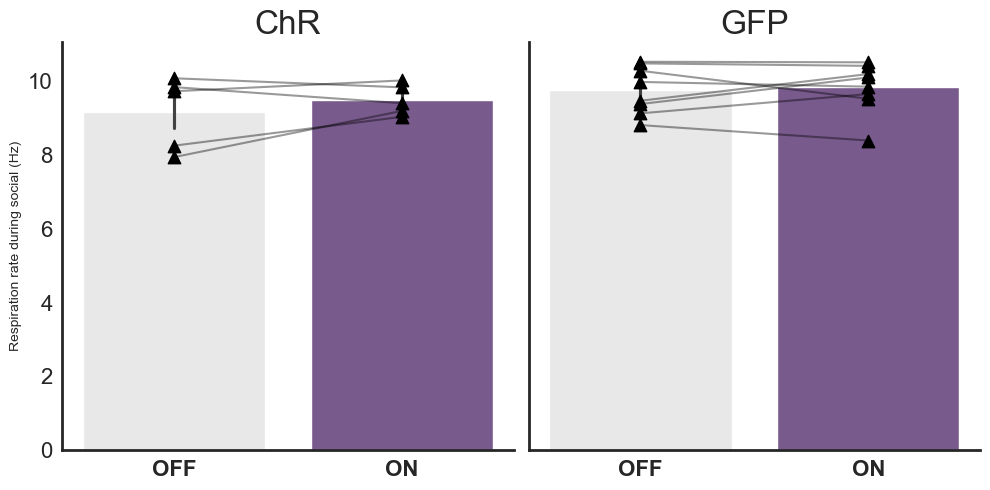

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("white")

laser_order = ["OFF", "ON"]
virus_order = ["ChR", "GFP"]

palette_laser = {
    "OFF": "#E8E8E8",
    "ON":  "#7A5195"   # Cohort 2
}

# ============================================================
# Plot dataframe
# ============================================================

df_plot = df_resp_clean.copy()

# RI1 only
df_plot = df_plot[
    df_plot["Condition"] == "RI1"
].copy()

# Check sample sizes
print(
    df_plot[
        ["Subject", "Virus"]
    ]
    .drop_duplicates()
    .groupby("Virus")
    .size()
)

# ============================================================
# Bar plot
# ============================================================

g = sns.catplot(
    data=df_plot,
    x="Laser",
    y="RespRate",
    col="Virus",
    kind="bar",
    order=laser_order,
    col_order=virus_order,
    palette=palette_laser,
    errorbar="se",
    height=5,
    aspect=1.0,
    sharey=True
)

# ============================================================
# Overlay individual paired mice
# ============================================================

for ax, virus in zip(g.axes.flat, virus_order):

    df_group = df_plot[
        df_plot["Virus"] == virus
    ]

    for subject, df_sub in df_group.groupby("Subject"):

        # Require both OFF and ON
        if set(laser_order).issubset(set(df_sub["Laser"])):

            df_sub = (
                df_sub
                .set_index("Laser")
                .loc[laser_order]
            )

            x = np.arange(len(laser_order))

            # Paired line
            ax.plot(
                x,
                df_sub["RespRate"],
                color="black",
                alpha=0.4,
                linewidth=1.5,
                zorder=3
            )

            # Individual mouse points — triangles for Cohort 2
            ax.scatter(
                x,
                df_sub["RespRate"],
                marker="^",
                color="black",
                s=80,
                zorder=4
            )

    # ========================================================
    # Formatting
    # ========================================================

    ax.set_xticks(np.arange(len(laser_order)))

    ax.set_xticklabels(
        laser_order,
        fontsize=18,
        fontweight="bold"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(2)
    ax.spines["bottom"].set_linewidth(2)

    ax.tick_params(
        width=2,
        labelsize=16
    )

# ============================================================
# Labels
# ============================================================

g.set_axis_labels(
    "",
    "Respiration rate during social (Hz)"
)

g.set_titles(
    "{col_name}",
    size=24
)

plt.tight_layout()
plt.show()

In [59]:
print(behavior_df.columns)
print(behavior_df.head())

NameError: name 'behavior_df' is not defined